# Desempenho dos Estudantes — limpeza e primeiras leituras

Duas metas hoje:
1. **Limpar** o dataset — sem apagar dado à toa.
2. **Olhar correlações** — com o cuidado das aulas passadas: média sozinha engana.

A regra do Lab 03 continua valendo: ao comparar grupos, relate sempre **centro, dispersão e tamanho**.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

result_path = "/content/RESULTADOS_2024.csv"
participate_path = "/content/PARTICIPANTES_2024.csv"

df_result = pd.read_csv(result_path, encoding='latin1', sep=';')
df_participate = pd.read_csv(participate_path, keep_default_na=False, na_values=["NA", ""], encoding='latin1', sep=';')

df = pd.merge(df_result, df_participate, left_on='NU_SEQUENCIAL', right_on='NU_INSCRICAO', how='outer')

print(df.shape)
df.head(3)

(59978, 80)


,NU_SEQUENCIAL,NU_ANO_x,CO_ESCOLA,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,...,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023
0,136.0,2024.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,336.0,2024.0,31115517.0,3147907.0,Passos,31.0,MG,2.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,603.0,2024.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Passo 1 · o que temos em mãos

Antes de mexer em nada: **quais colunas existem, de que tipo, e onde faltam dados.**

Rode e anote os nomes das colunas — vamos precisar deles nas lacunas mais à frente.

In [ ]:
df.columns.tolist()

['NU_SEQUENCIAL',
 'NU_ANO_x',
 'CO_ESCOLA',
 'CO_MUNICIPIO_ESC',
 'NO_MUNICIPIO_ESC',
 'CO_UF_ESC',
 'SG_UF_ESC',
 'TP_DEPENDENCIA_ADM_ESC',
 'TP_LOCALIZACAO_ESC',
 'TP_SIT_FUNC_ESC',
 'CO_MUNICIPIO_PROVA_x',
 'NO_MUNICIPIO_PROVA_x',
 'CO_UF_PROVA_x',
 'SG_UF_PROVA_x',
 'TP_PRESENCA_CN',
 'TP_PRESENCA_CH',
 'TP_PRESENCA_LC',
 'TP_PRESENCA_MT',
 'CO_PROVA_CN',
 'CO_PROVA_CH',
 'CO_PROVA_LC',
 'CO_PROVA_MT',
 'NU_NOTA_CN',
 'NU_NOTA_CH',
 'NU_NOTA_LC',
 'NU_NOTA_MT',
 'TX_RESPOSTAS_CN',
 'TX_RESPOSTAS_CH',
 'TX_RESPOSTAS_LC',
 'TX_RESPOSTAS_MT',
 'TP_LINGUA',
 'TX_GABARITO_CN',
 'TX_GABARITO_CH',
 'TX_GABARITO_LC',
 'TX_GABARITO_MT',
 'TP_STATUS_REDACAO',
 'NU_NOTA_COMP1',
 'NU_NOTA_COMP2',
 'NU_NOTA_COMP3',
 'NU_NOTA_COMP4',
 'NU_NOTA_COMP5',
 'NU_NOTA_REDACAO',
 'NU_INSCRICAO',
 'NU_ANO_y',
 'TP_FAIXA_ETARIA',
 'TP_SEXO',
 'TP_ESTADO_CIVIL',
 'TP_COR_RACA',
 'TP_NACIONALIDADE',
 'TP_ST_CONCLUSAO',
 'TP_ANO_CONCLUIU',
 'TP_ENSINO',
 'IN_TREINEIRO',
 'CO_MUNICIPIO_PROVA_y',
 'NO_MUNICIP

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59978 entries, 0 to 59977
Data columns (total 80 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   NU_SEQUENCIAL           10812 non-null  float64
 1   NU_ANO_x                10812 non-null  float64
 2   CO_ESCOLA               3936 non-null   float64
 3   CO_MUNICIPIO_ESC        3936 non-null   float64
 4   NO_MUNICIPIO_ESC        3935 non-null   object 
 5   CO_UF_ESC               3935 non-null   float64
 6   SG_UF_ESC               3935 non-null   object 
 7   TP_DEPENDENCIA_ADM_ESC  3935 non-null   float64
 8   TP_LOCALIZACAO_ESC      3935 non-null   float64
 9   TP_SIT_FUNC_ESC         3935 non-null   float64
 10  CO_MUNICIPIO_PROVA_x    10811 non-null  float64
 11  NO_MUNICIPIO_PROVA_x    10811 non-null  object 
 12  CO_UF_PROVA_x           10811 non-null  float64
 13  SG_UF_PROVA_x           10811 non-null  object 
 14  TP_PRESENCA_CN          10811 non-null

In [ ]:
# onde faltam dados, e há linhas repetidas?
print(df.isna().sum())
print("\nDuplicatas:", df.duplicated().sum())

NU_SEQUENCIAL       49166
NU_ANO_x            49166
CO_ESCOLA           56042
CO_MUNICIPIO_ESC    56042
NO_MUNICIPIO_ESC    56043
                    ...  
Q019                10813
Q020                10813
Q021                10813
Q022                10813
Q023                10813
Length: 80, dtype: int64

Duplicatas: 0


## Passo 2 · limpeza

Quatro coisas, e o **porquê** de cada uma:

- **Nomes das colunas** em minúsculas e sem espaço → para não errar ao digitar depois.
- **Duplicatas fora** → o mesmo estudante contado duas vezes puxa qualquer média.
- **Espaços nos textos** → `"A "` e `"A"` viram categorias diferentes se não limpar.
- **Valores ausentes**: não apagamos a linha (perderíamos as outras colunas dela). Preenchemos — mediana para número, moda para categoria.


In [ ]:
# nomes limpos
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# duplicatas fora
df = df.drop_duplicates()

# espaços nos textos
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

# ausentes: mediana p/ número, moda p/ categoria
for col in df.columns:
    if df[col].dtype in ["float64", "int64"]:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Ausentes depois:", df.isna().sum().sum())
print("Formato:", df.shape)

Ausentes depois: 0
Formato: (59978, 80)


## Passo 3 · como cada nota se distribui

Antes de correlacionar: **olhar uma variável de cada vez.** O histograma mostra se as notas se concentram numa faixa, se há valores extremos, se a distribuição é torta.

> Uma correlação pode ser puxada por poucos valores extremos — por isso olhamos a distribuição **antes**.

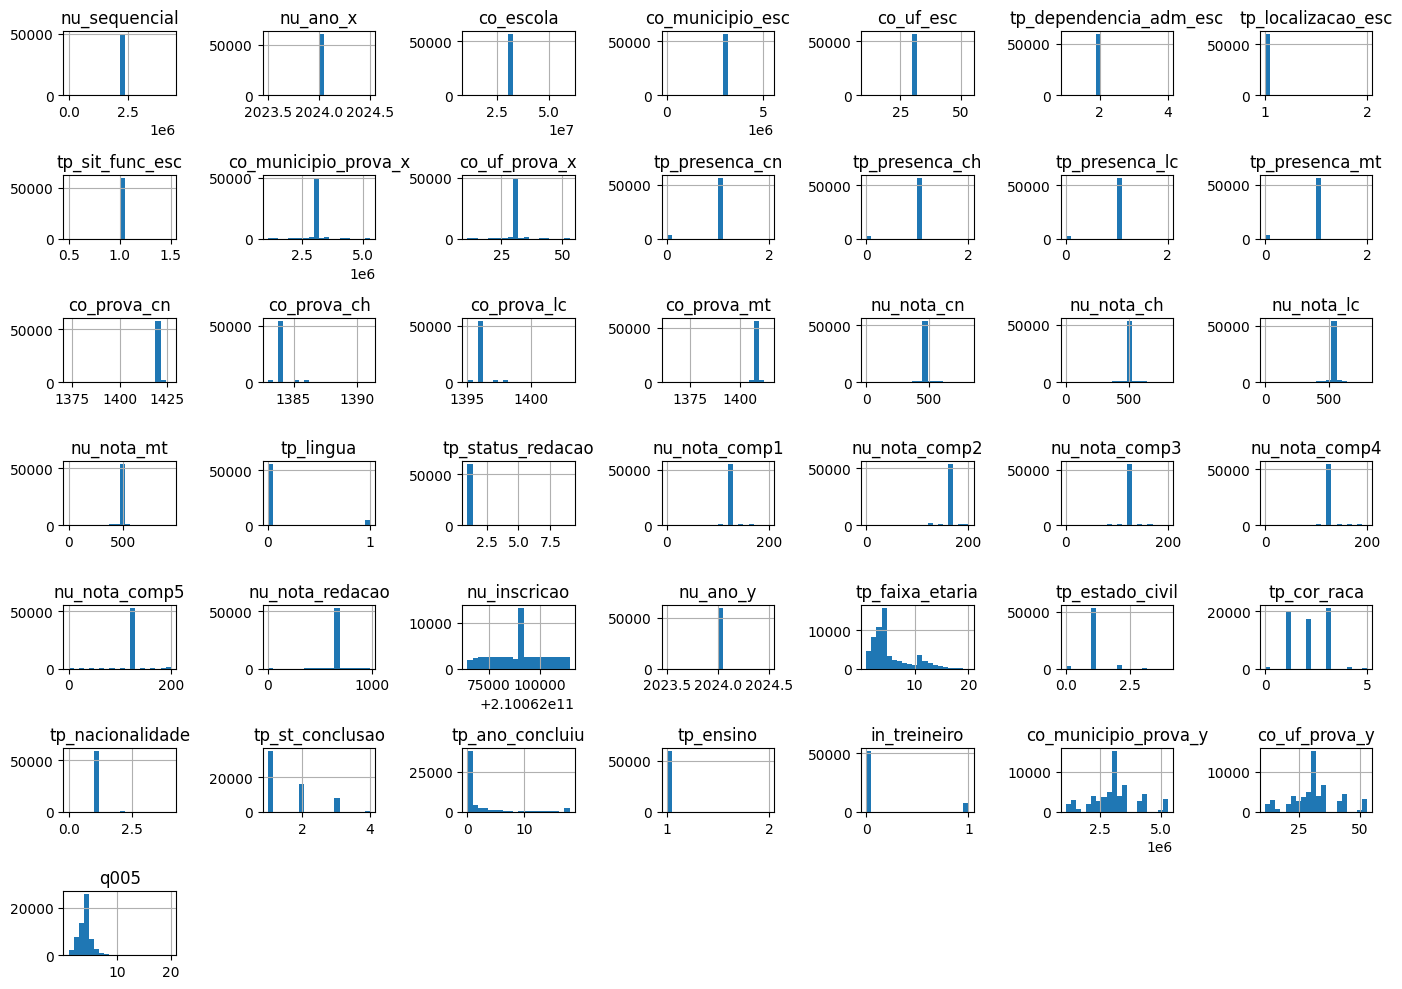

In [ ]:
num_df = df.select_dtypes(include="number")

num_df.hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

## Passo 4 · a matriz de correlação

A correlação vai de **-1 a +1**:
- perto de **+1** → sobem juntas;
- perto de **-1** → uma sobe, a outra desce;
- perto de **0** → sem relação linear.


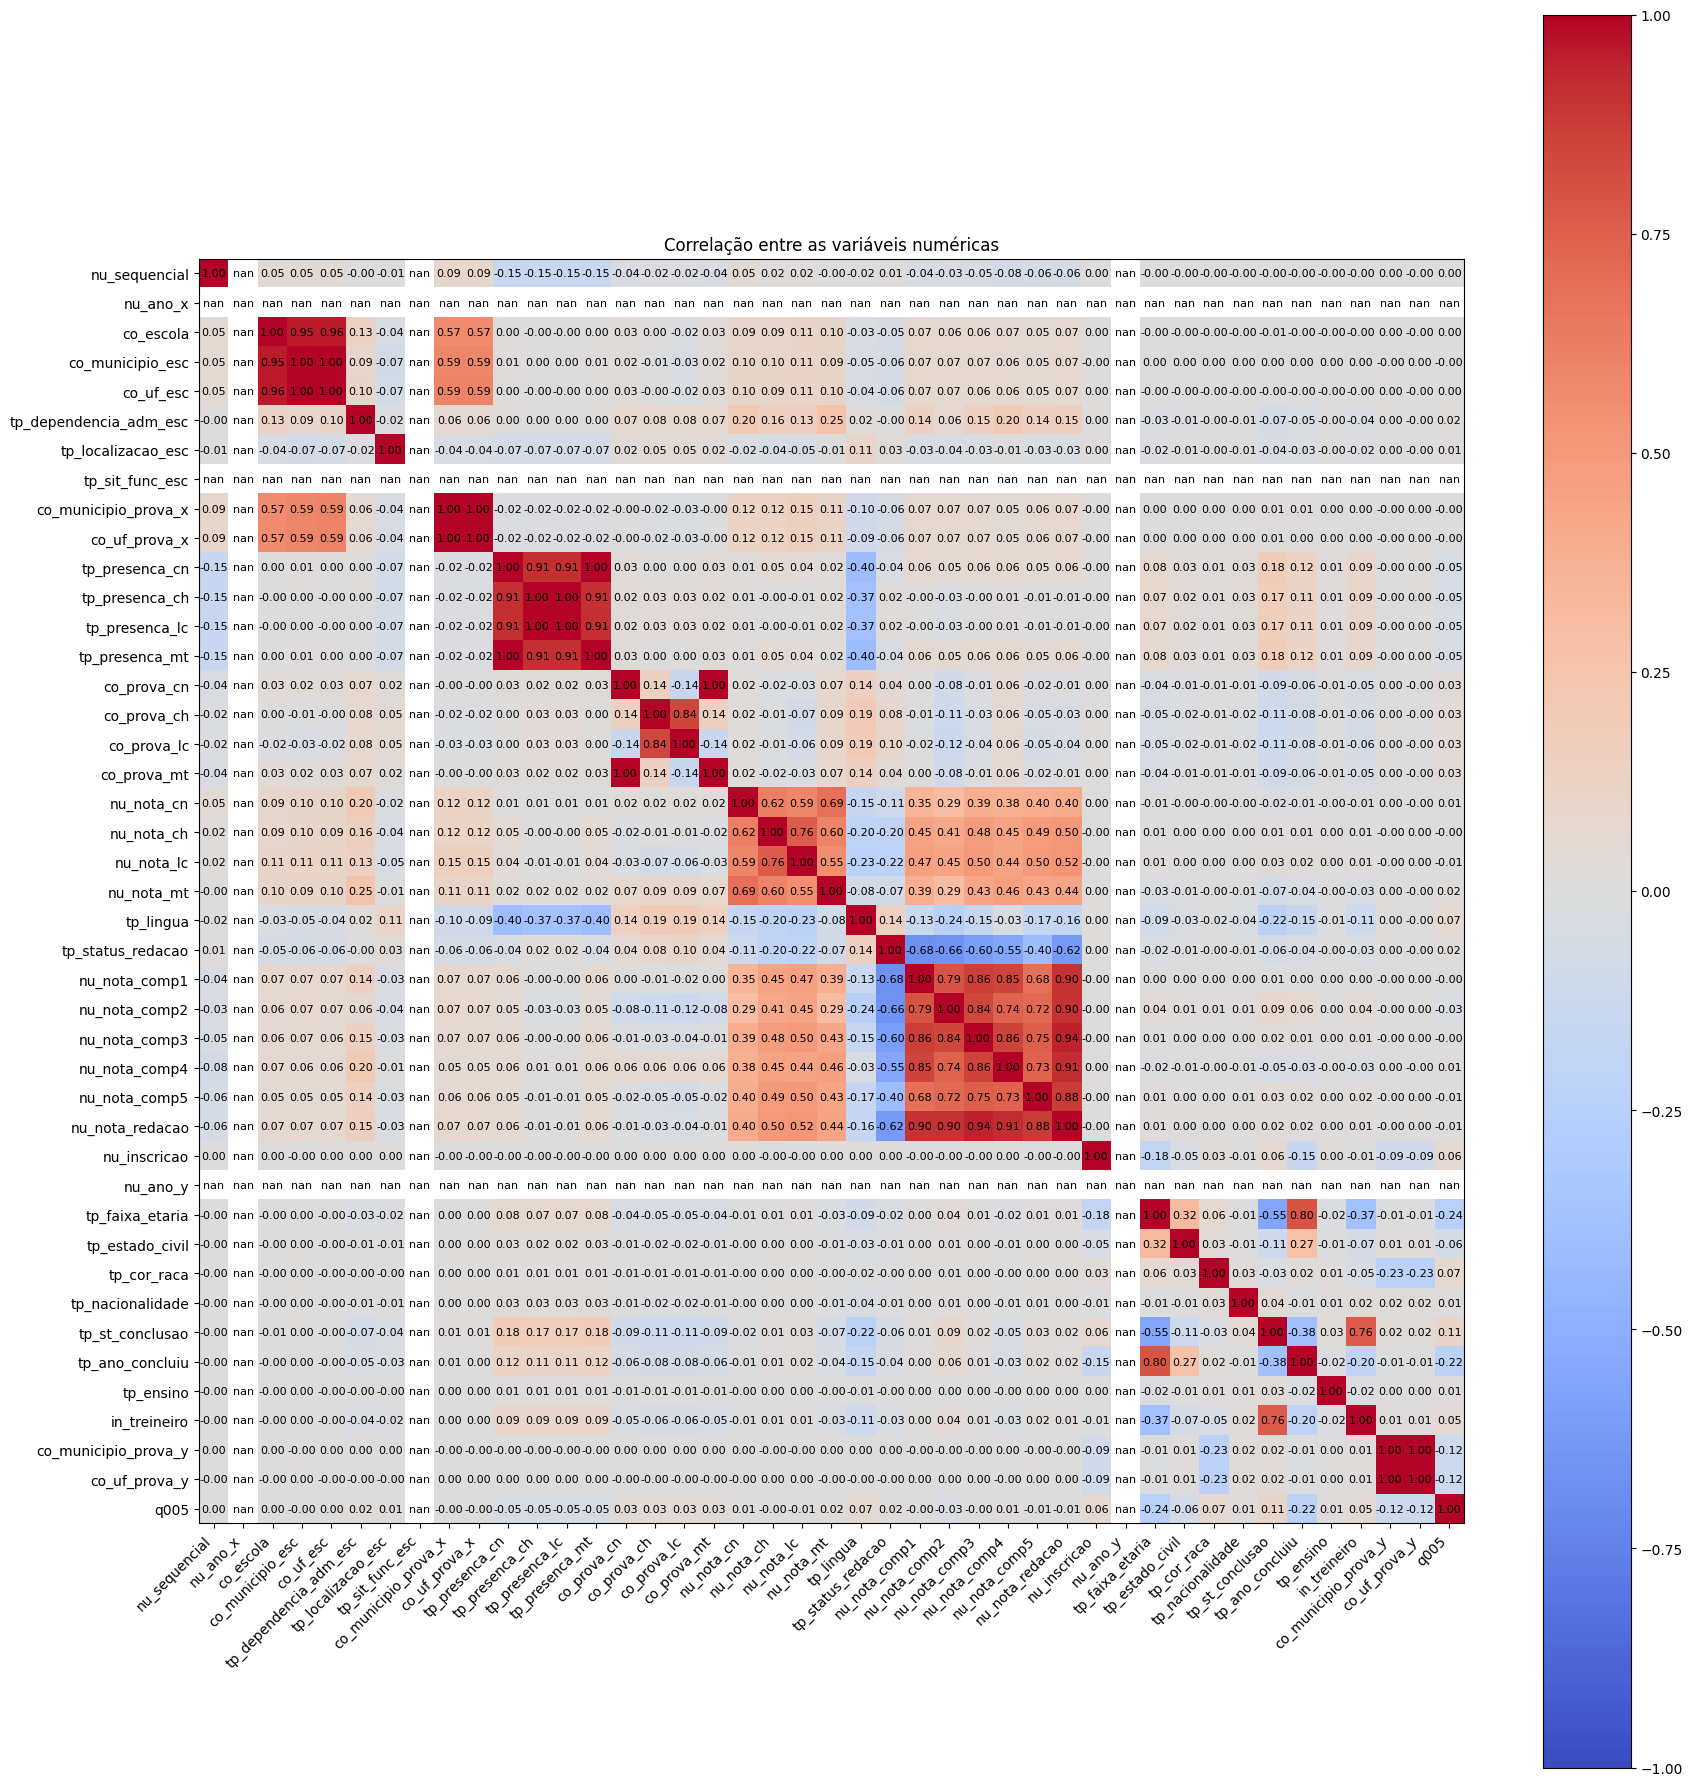

In [ ]:
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(18, 18))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

# escreve o valor em cada célula
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax)
ax.set_title("Correlação entre as variáveis numéricas")
plt.tight_layout()
plt.show()

## Passo 5 · a pergunta central — a região/escola tem ensino de qualidade?

Até aqui olhamos as notas em geral. Agora respondemos ao objetivo do trabalho:
**naquela região e naquela escola, o nível de ensino está bom — na rede pública e na privada?**

Para isso precisamos de três ingredientes, todos já presentes nos microdados do ENEM:


- **A nota** — vamos criar uma nota geral, média das 5 áreas (CN, CH, LC, MT e Redação).
- **A rede** — `tp_dependencia_adm_esc` diz se a escola é Federal, Estadual, Municipal ou Privada;
  `tp_escola` diz se o participante é da rede pública ou privada.
- **A região** — `sg_uf_esc`/`sg_uf_prova` (UF) e `no_municipio_esc`/`no_municipio_prova` (município).

> Lembre da regra do Lab 03: ao comparar grupos, sempre **centro, dispersão e tamanho**.
> Uma média alta de uma escola com 3 alunos não diz nada.


In [ ]:
# as cinco notas do ENEM (nomes já em minúsculo por causa da limpeza do Passo 2)
notas = ["nu_nota_cn", "nu_nota_ch", "nu_nota_lc", "nu_nota_mt", "nu_nota_redacao"]

# garante que estão como número (vazio/traço vira NaN)
for c in notas:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# só quem tem as cinco notas E tirou nota > 0 em todas (presente e válido)
presentes = df[(df[notas] > 0).all(axis=1)].copy()

# nota geral = média das cinco áreas
presentes["nota_geral"] = presentes[notas].mean(axis=1)

print("Participantes no total:", len(df))
print("Participantes presentes e válidos:", len(presentes))
print("Nota geral — média:", round(presentes["nota_geral"].mean(), 1))
presentes["nota_geral"].describe().round(1)

Participantes no total: 59978
Participantes presentes e válidos: 59554
Nota geral — média: 535.3


,nota_geral
count,59554.0
mean,535.3
std,29.6
min,313.1
25%,533.9
50%,533.9
75%,533.9
max,804.7


In [ ]:
dep_map = {1: "Federal", 2: "Estadual", 3: "Municipal", 4: "Privada",
           "1": "Federal", "2": "Estadual", "3": "Municipal", "4": "Privada"}

presentes["rede_detalhada"] = presentes["tp_dependencia_adm_esc"].map(dep_map).fillna("Não informado")

# rede resumida: Pública (Federal+Estadual+Municipal) vs Privada
def resume(r):
    if r in ["Federal", "Estadual", "Municipal"]:
        return "Pública"
    if r == "Privada":
        return "Privada"
    return "Não informado"

presentes["rede_publica_privada"] = presentes["rede_detalhada"].apply(resume)

presentes["rede_publica_privada"].value_counts()

,count
rede_publica_privada,
Pública,58902
Privada,652


In [ ]:
resumo_rede = (presentes
    .groupby("rede_publica_privada")["nota_geral"]
    .agg(alunos="count", media="mean", mediana="median", desvio="std", minimo="min", maximo="max")
    .round(1)
    .sort_values("media", ascending=False))

resumo_rede         # que valores existem? procura "", "Unknown", " "


,alunos,media,mediana,desvio,minimo,maximo
rede_publica_privada,,,,,,
Privada,652,612.9,616.2,75.9,397.8,799.1
Pública,58902,534.4,533.9,27.5,313.1,804.7


In [ ]:
resumo_detalhado = (presentes
    .groupby("rede_detalhada")["nota_geral"]
    .agg(alunos="count", media="mean", mediana="median", desvio="std")
    .round(1)
    .sort_values("media", ascending=False))

resumo_detalhado

,alunos,media,mediana,desvio
rede_detalhada,,,,
Privada,652,612.9,616.2,75.9
Federal,150,588.0,592.3,75.2
Municipal,17,534.7,526.4,65.3
Estadual,58735,534.3,533.9,27.1


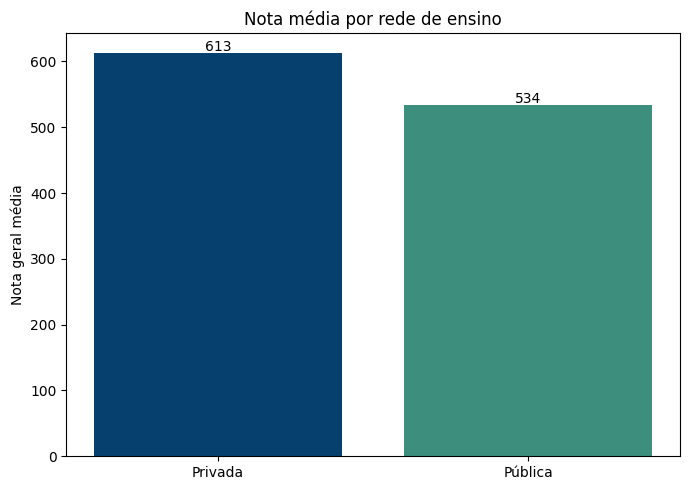

In [ ]:
# gráfico de barras: nota média por rede
ordem = resumo_rede.index.tolist()
medias = resumo_rede["media"].values

fig, ax = plt.subplots(figsize=(7, 5))
barras = ax.bar(ordem, medias, color=["#06406F", "#3E8E7E", "#B0B0B0"][:len(ordem)])
ax.set_ylabel("Nota geral média")
ax.set_title("Nota média por rede de ensino")
for b, v in zip(barras, medias):
    ax.text(b.get_x() + b.get_width()/2, v + 3, f"{v:.0f}", ha="center")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1440/3617359936.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grupos, labels=rotulos, showfliers=False)


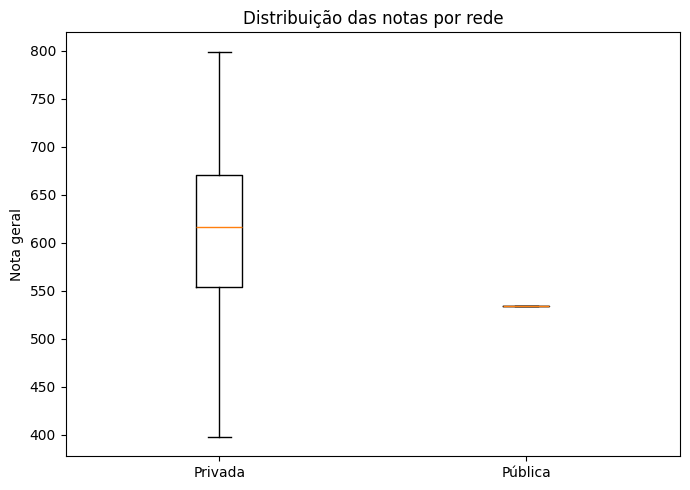

In [ ]:
grupos = [g["nota_geral"].values for _, g in presentes.groupby("rede_publica_privada")]
rotulos = [nome for nome, _ in presentes.groupby("rede_publica_privada")]

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot(grupos, labels=rotulos, showfliers=False)
ax.set_ylabel("Nota geral")
ax.set_title("Distribuição das notas por rede")
plt.tight_layout()
plt.show()

In [ ]:
por_uf = (presentes
    .groupby(["sg_uf_esc", "rede_publica_privada"])["nota_geral"]
    .agg(alunos="count", media="mean")
    .round(1)
    .reset_index())

# tabela lado a lado: uma coluna por rede
tabela_uf = por_uf.pivot(index="sg_uf_esc", columns="rede_publica_privada", values="media")
tabela_uf["diferenca_priv_menos_pub"] = (tabela_uf.get("Privada") - tabela_uf.get("Pública")).round(1)
tabela_uf.sort_values("diferenca_priv_menos_pub", ascending=False)


rede_publica_privada,Privada,Pública,diferenca_priv_menos_pub
sg_uf_esc,,,
AC,658.9,509.0,149.9
PI,643.7,512.6,131.1
GO,656.5,528.6,127.9
MG,649.0,531.2,117.8
MS,641.1,523.3,117.8
PB,625.8,515.6,110.2
AM,613.7,511.6,102.1
CE,624.2,524.4,99.8
MA,606.9,507.9,99.0


In [ ]:
uf_alvo = "RJ"   # <- troque pela UF que você quer analisar

recorte = presentes[presentes["sg_uf_esc"] == uf_alvo]

print(f"Região analisada: {uf_alvo}  ({len(recorte)} alunos presentes)")
resumo_regiao = (recorte
    .groupby("rede_publica_privada")["nota_geral"]
    .agg(alunos="count", media="mean", mediana="median", desvio="std")
    .round(1)
    .sort_values("media", ascending=False))
resumo_regiao

Região analisada: RJ  (217 alunos presentes)


,alunos,media,mediana,desvio
rede_publica_privada,,,,
Privada,69,612.2,621.9,73.1
Pública,148,523.7,533.9,59.0


In [ ]:
MIN_ALUNOS = 20   # escolas com menos alunos que isso são descartadas do ranking

por_escola = (recorte
    .groupby(["co_escola", "no_municipio_esc", "rede_detalhada"])["nota_geral"]
    .agg(alunos="count", media="mean", mediana="median")
    .round(1)
    .reset_index())

ranking = (por_escola[por_escola["alunos"] >= MIN_ALUNOS]
           .sort_values("media", ascending=False))

print(f"Escolas com pelo menos {MIN_ALUNOS} alunos em {uf_alvo}: {len(ranking)}")
print("\nTop 10 escolas:")
print(ranking.head(10).to_string(index=False))
print("\n10 escolas com menor média:")
print(ranking.tail(10).to_string(index=False))

Escolas com pelo menos 20 alunos em RJ: 0

Top 10 escolas:
Empty DataFrame
Columns: [co_escola, no_municipio_esc, rede_detalhada, alunos, media, mediana]
Index: []

10 escolas com menor média:
Empty DataFrame
Columns: [co_escola, no_municipio_esc, rede_detalhada, alunos, media, mediana]
Index: []


In [ ]:
ref_nacional = presentes["nota_geral"].mean()
print(f"Média nacional (presentes): {ref_nacional:.1f}\n")

comparacao = resumo_regiao.copy()
comparacao["vs_nacional"] = (comparacao["media"] - ref_nacional).round(1)
comparacao["situacao"] = comparacao["vs_nacional"].apply(
    lambda d: "acima da média nacional" if d >= 0 else "abaixo da média nacional")

print(f"Situação de cada rede em {uf_alvo}:")
comparacao[["alunos", "media", "vs_nacional", "situacao"]]

Média nacional (presentes): 535.3

Situação de cada rede em RJ:


,alunos,media,vs_nacional,situacao
rede_publica_privada,,,,
Privada,69,612.2,76.9,acima da média nacional
Pública,148,523.7,-11.6,abaixo da média nacional


In [ ]:
if "q006" in presentes.columns:
    tab = (presentes
        .groupby(["q006", "rede_publica_privada"])["nota_geral"]
        .agg(alunos="count", media="mean")
        .round(1)
        .reset_index())
    print(tab.pivot(index="q006", columns="rede_publica_privada", values="media").to_string())
else:
    print("Coluna q006 (renda) não encontrada neste recorte de dados.")

rede_publica_privada  Privada  Pública
q006                                  
A                       612.9    534.6
B                         NaN    533.9
